# Laboratorio 1 — Series de Tiempo

## Análisis exploratorio general y serie total mensual

Este notebook contiene la preparación de datos, control de calidad, análisis exploratorio general y análisis preliminar de la serie obligatoria de viajeros internacionales.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

ROOT = Path.cwd()
INPUT = ROOT / 'data' / 'data.xlsx'
OUT = ROOT / 'resultados_laboratorio_1'
FIG = OUT / 'figuras'
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 140

def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(FIG / nombre, bbox_inches='tight')

def fmt(valor):
    return f'{valor:,.0f}'


## 1. Carga, tipos de datos y calidad

Se eliminan únicamente duplicados exactos y registros sin fecha o cantidad válida. Los valores atípicos se identifican, pero no se eliminan automáticamente: pueden ser flujos reales y quitarlos distorsionaría los totales mensuales.

In [2]:
datos = pd.read_excel(INPUT, sheet_name='Datos')
datos.columns = datos.columns.str.strip()
filas_iniciales = len(datos)

datos['Año'] = pd.to_numeric(datos['Año'], errors='coerce')
datos['Mes cod'] = pd.to_numeric(datos['Mes cod'], errors='coerce')
datos['Viajero'] = pd.to_numeric(datos['Viajero'], errors='coerce')
datos['fecha'] = pd.to_datetime(dict(year=datos['Año'], month=datos['Mes cod'], day=1), errors='coerce')

duplicados = int(datos.duplicated().sum())
datos = datos.drop_duplicates().copy()
validos = datos['fecha'].notna() & datos['Viajero'].notna() & datos['Viajero'].ge(0)
filas_excluidas = int((~validos).sum())
datos = datos.loc[validos].copy()

q1, q3 = datos['Viajero'].quantile([.25, .75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
atipicos = int(((datos['Viajero'] < lim_inf) | (datos['Viajero'] > lim_sup)).sum())
faltantes = datos.drop(columns='fecha').isna().sum().sort_values(ascending=False)

calidad = pd.DataFrame({'Indicador': ['Filas originales', 'Duplicados exactos eliminados', 'Filas excluidas por fecha/cantidad inválida', 'Filas finales', 'Valores faltantes restantes', 'Atípicos IQR en registros', 'Límite superior IQR'],
                        'Valor': [filas_iniciales, duplicados, filas_excluidas, len(datos), int(faltantes.sum()), atipicos, lim_sup]})
display(calidad)
display(pd.DataFrame({'Variable': faltantes.index, 'Faltantes': faltantes.values, 'Porcentaje': (faltantes.values/len(datos)*100).round(2)}))
display(datos['Viajero'].describe(percentiles=[.25, .5, .75, .95, .99]).to_frame('Viajero'))

calidad.to_csv(OUT / 'calidad_datos.csv', index=False, encoding='utf-8-sig')
pd.DataFrame({'variable': faltantes.index, 'valores_faltantes': faltantes.values, 'porcentaje': (faltantes.values/len(datos)*100).round(2)}).to_csv(OUT / 'valores_faltantes.csv', index=False, encoding='utf-8-sig')
datos['Viajero'].describe(percentiles=[.25, .5, .75, .95, .99]).to_frame('Viajero').to_csv(OUT / 'estadisticas_viajero.csv', encoding='utf-8-sig')

,Indicador,Valor
0,Filas originales,161036.000000
1,Duplicados exactos eliminados,0.000000
2,Filas excluidas por fecha/cantidad inválida,0.000000
3,Filas finales,161036.000000
4,Valores faltantes restantes,0.000000
5,Atípicos IQR en registros,26390.000000
6,Límite superior IQR,94.229167


,Variable,Faltantes,Porcentaje
0,Año,0,0.0
1,Mes cod,0,0.0
2,Mes,0,0.0
3,Vía,0,0.0
4,Frontera,0,0.0
5,País,0,0.0
6,Región,0,0.0
7,Región dos,0,0.0
8,Regiones OMT,0,0.0
9,MCEO,0,0.0


,Viajero
count,161036.000000
mean,324.697193
std,2387.745140
min,0.000000
25%,2.000000
50%,7.000000
75%,38.891667
95%,858.261181
99%,6113.919887
max,92336.035067


## 2. Análisis exploratorio general

La serie `Turista + Excursionista` se presenta como comparación suplementaria, porque el enunciado advierte que `Viajero` cambia de definición entre 2022 y 2023. La serie total reportada se conserva como la serie obligatoria.

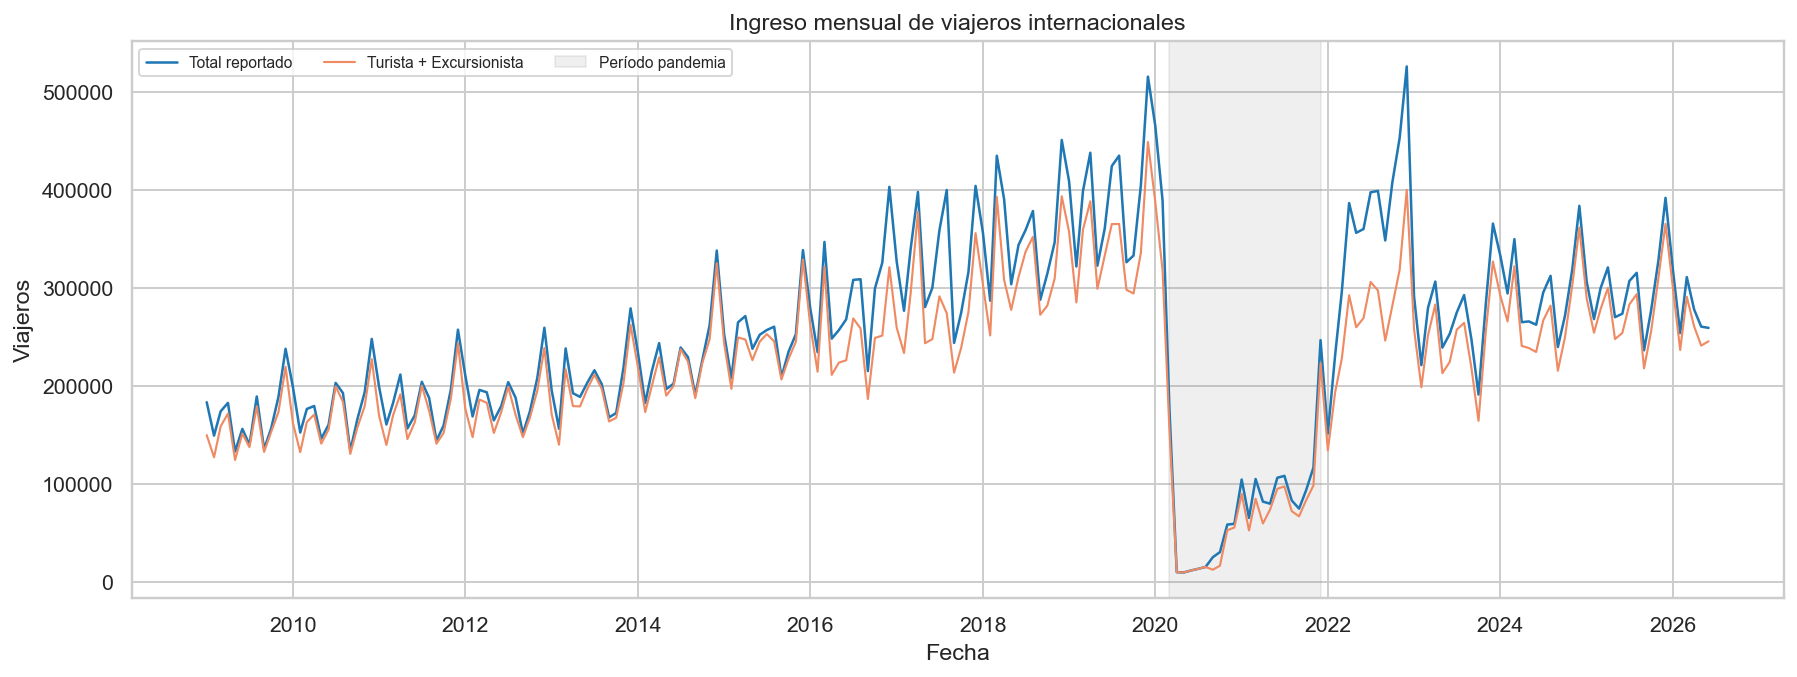

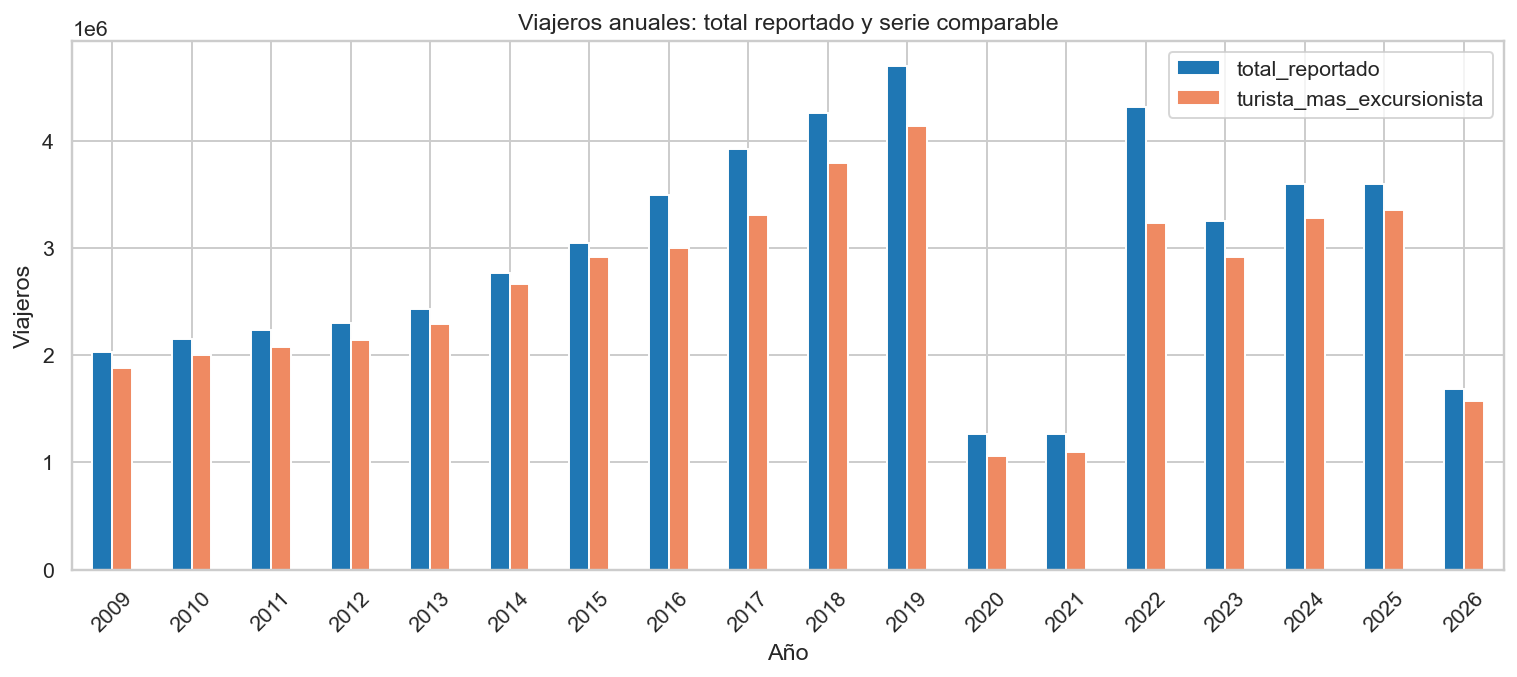

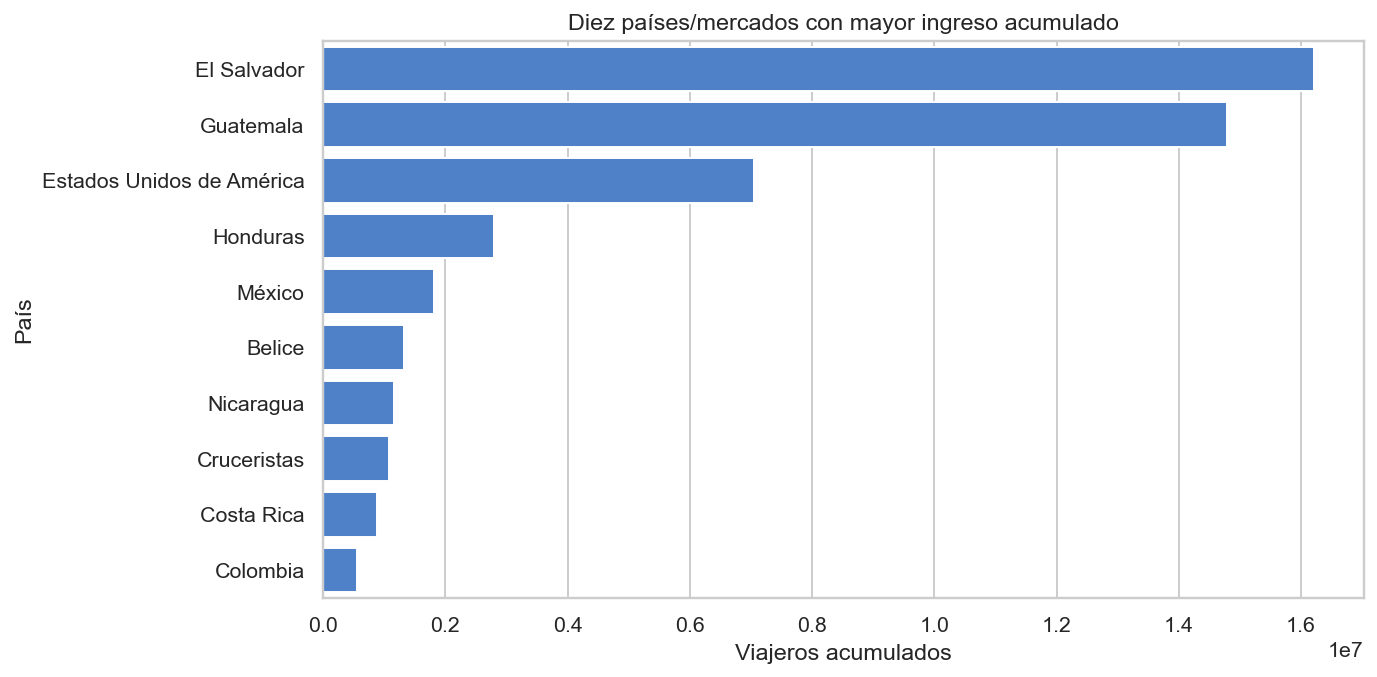

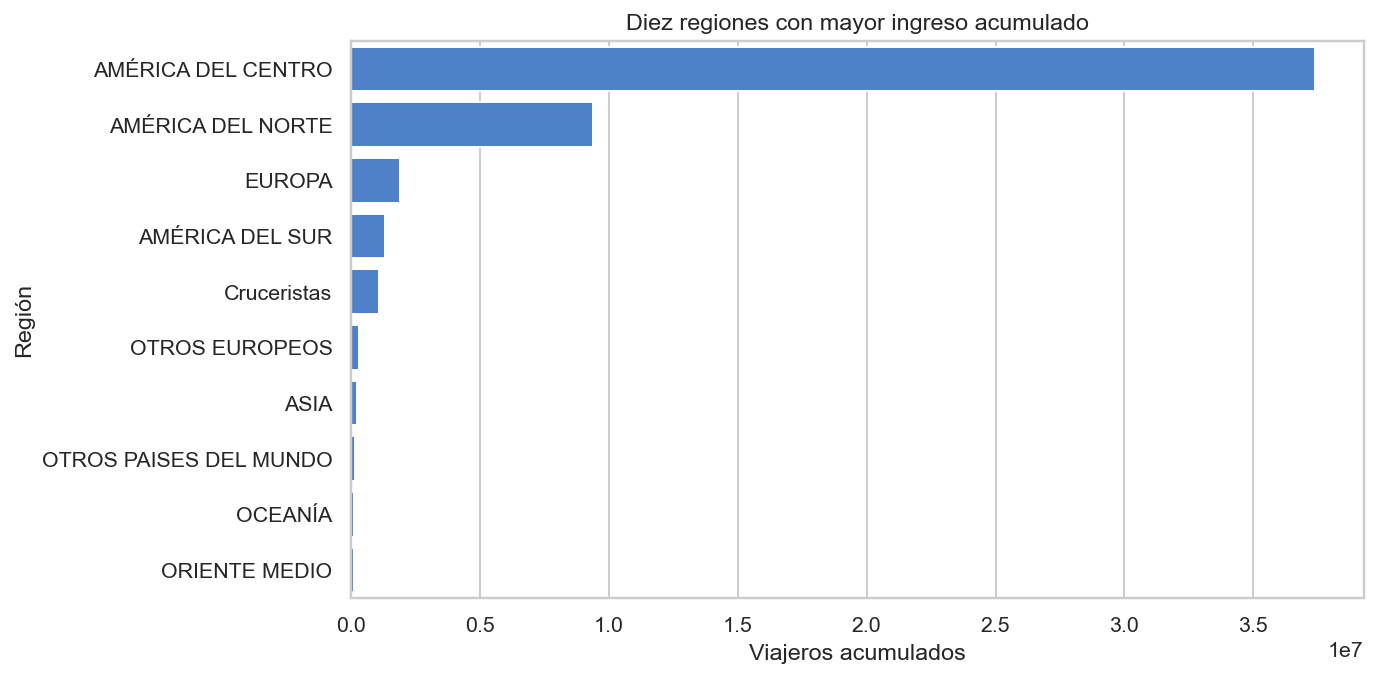

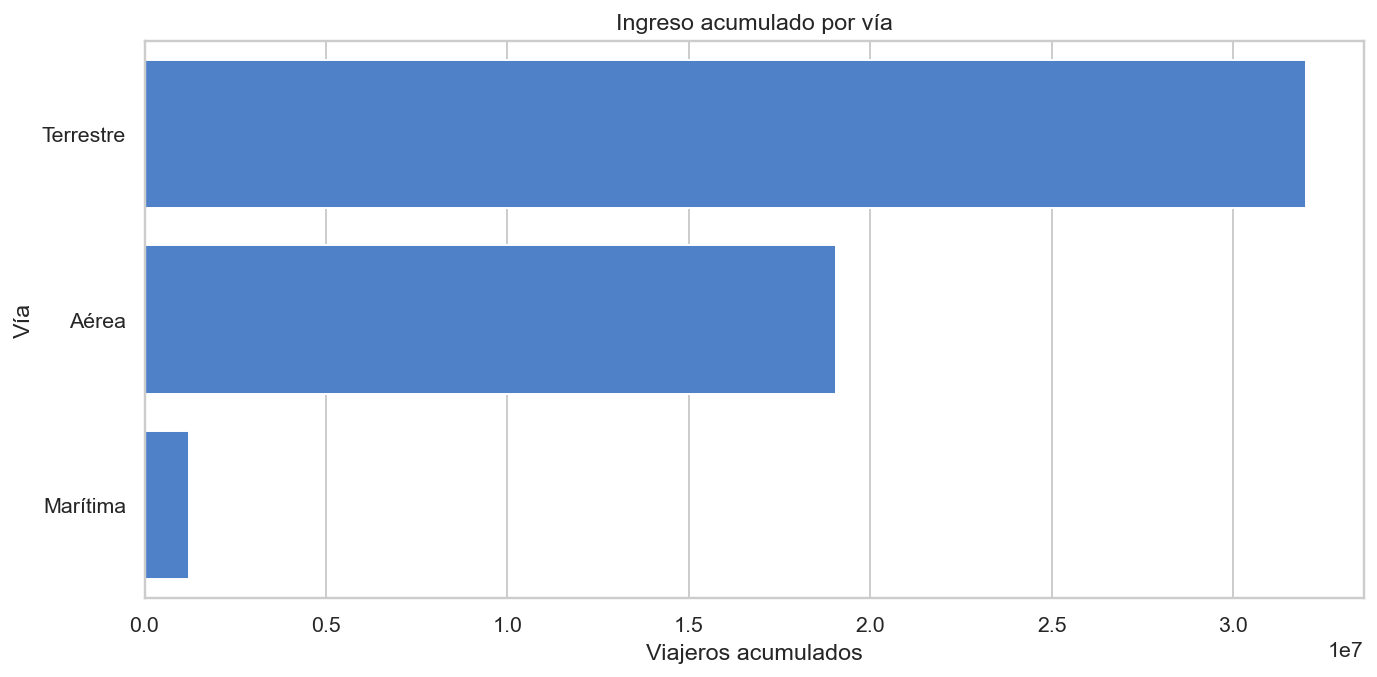

In [3]:
total = datos.groupby('fecha')['Viajero'].sum().sort_index().asfreq('MS', fill_value=0)
comparable = (datos.loc[datos['Tipo de Viajero'].isin(['Turista', 'Excursionista'])].groupby('fecha')['Viajero'].sum().sort_index().reindex(total.index, fill_value=0))
series = pd.DataFrame({'total_reportado': total, 'turista_mas_excursionista': comparable})
anual = series.resample('YS').sum()
anual.index = anual.index.year
anual.index.name = 'año'
series.to_csv(OUT / 'series_totales_mensuales.csv', encoding='utf-8-sig')
anual.to_csv(OUT / 'resumen_anual.csv', encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(total, label='Total reportado', color='#1f77b4', linewidth=1.3)
ax.plot(comparable, label='Turista + Excursionista', color='#ef8a62', linewidth=1.1)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), color='grey', alpha=.12, label='Período pandemia')
ax.set(title='Ingreso mensual de viajeros internacionales', xlabel='Fecha', ylabel='Viajeros')
ax.legend(ncol=3, fontsize=8)
guardar(fig, '01_serie_total_mensual.png')
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
anual.plot(kind='bar', ax=ax, color=['#1f77b4', '#ef8a62'])
ax.set(title='Viajeros anuales: total reportado y serie comparable', xlabel='Año', ylabel='Viajeros')
ax.tick_params(axis='x', rotation=45)
guardar(fig, '02_resumen_anual.png')
plt.show()

for columna, archivo, titulo in [('País', '03_top_paises.png', 'Diez países/mercados con mayor ingreso acumulado'), ('Región', '04_top_regiones.png', 'Diez regiones con mayor ingreso acumulado'), ('Vía', '05_vias_ingreso.png', 'Ingreso acumulado por vía')]:
    top = datos.groupby(columna)['Viajero'].sum().sort_values(ascending=False).head(10)
    top.to_frame('viajeros').to_csv(OUT / f"top_{columna.lower().replace(' ', '_')}.csv", encoding='utf-8-sig')
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=top.values, y=top.index.astype(str), ax=ax, color='#3b7ddd')
    ax.set(title=titulo, xlabel='Viajeros acumulados', ylabel=columna)
    guardar(fig, archivo)
    plt.show()

## 3. Análisis preliminar — Total mensual de viajeros internacionales

Se evalúan inicio, fin y frecuencia; comportamiento gráfico; descomposición; ACF y prueba Dickey-Fuller Aumentada (ADF).

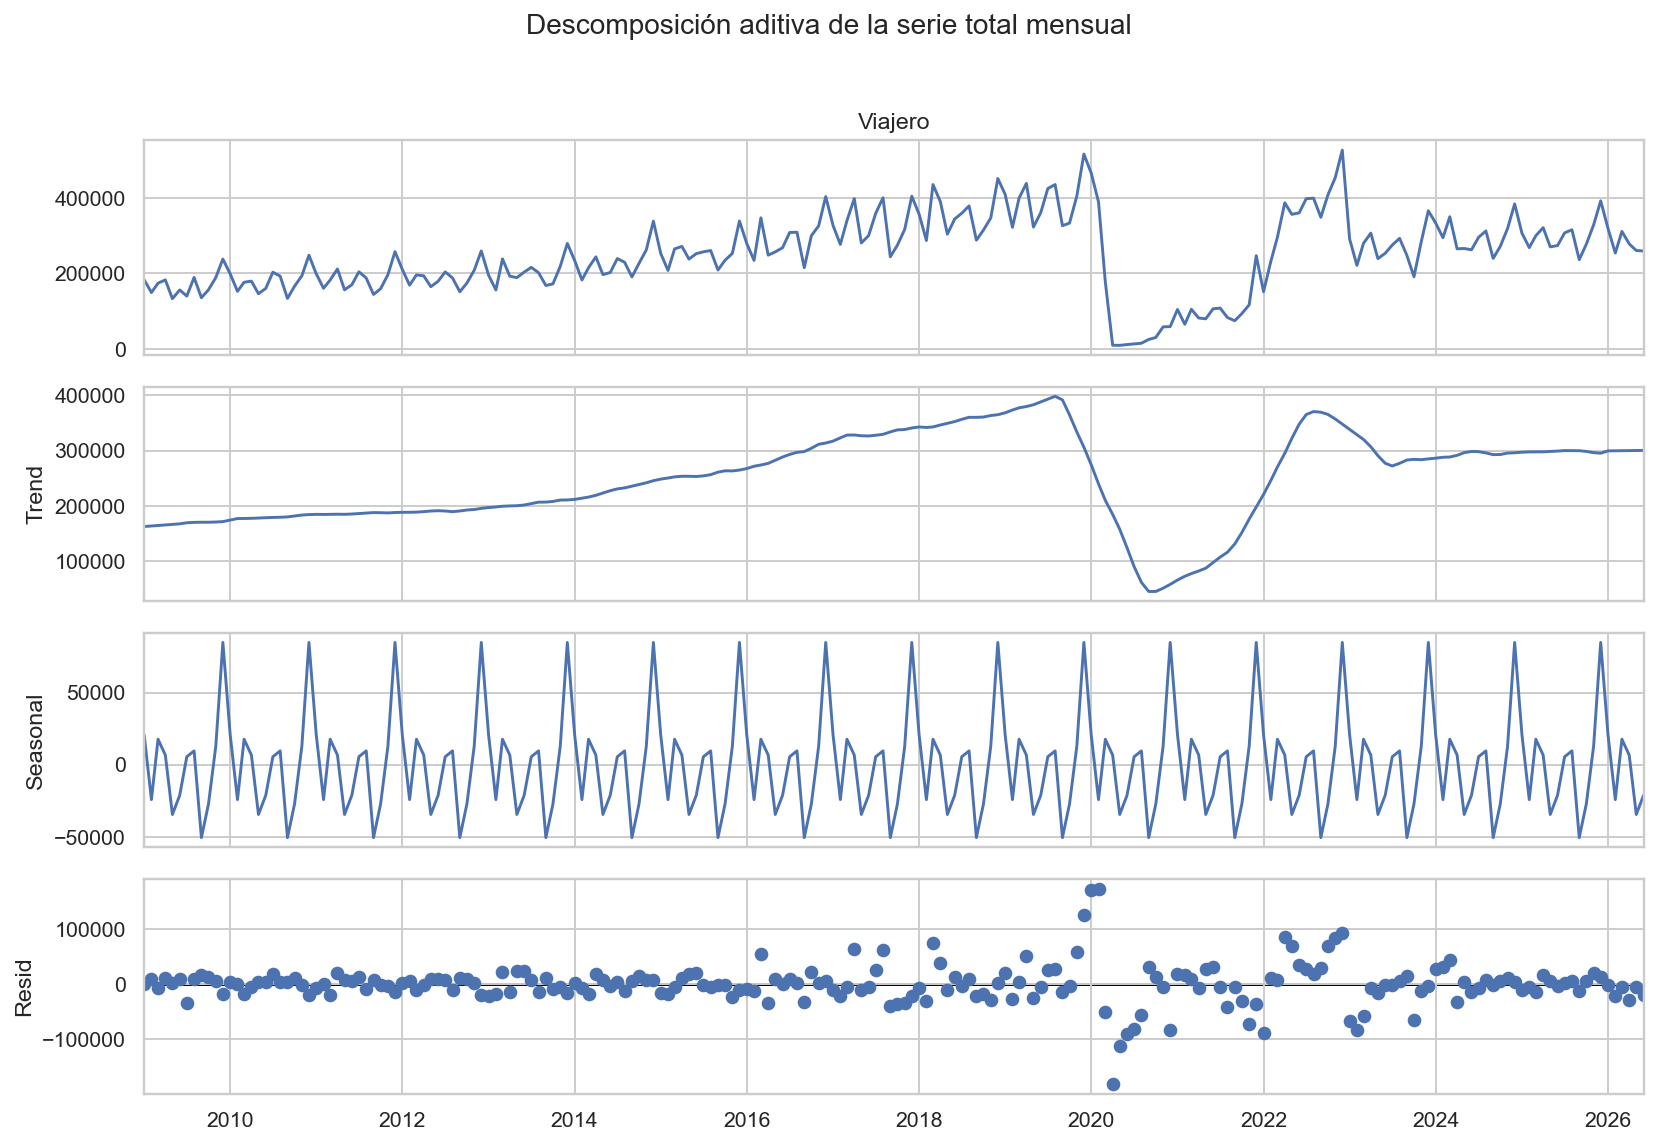

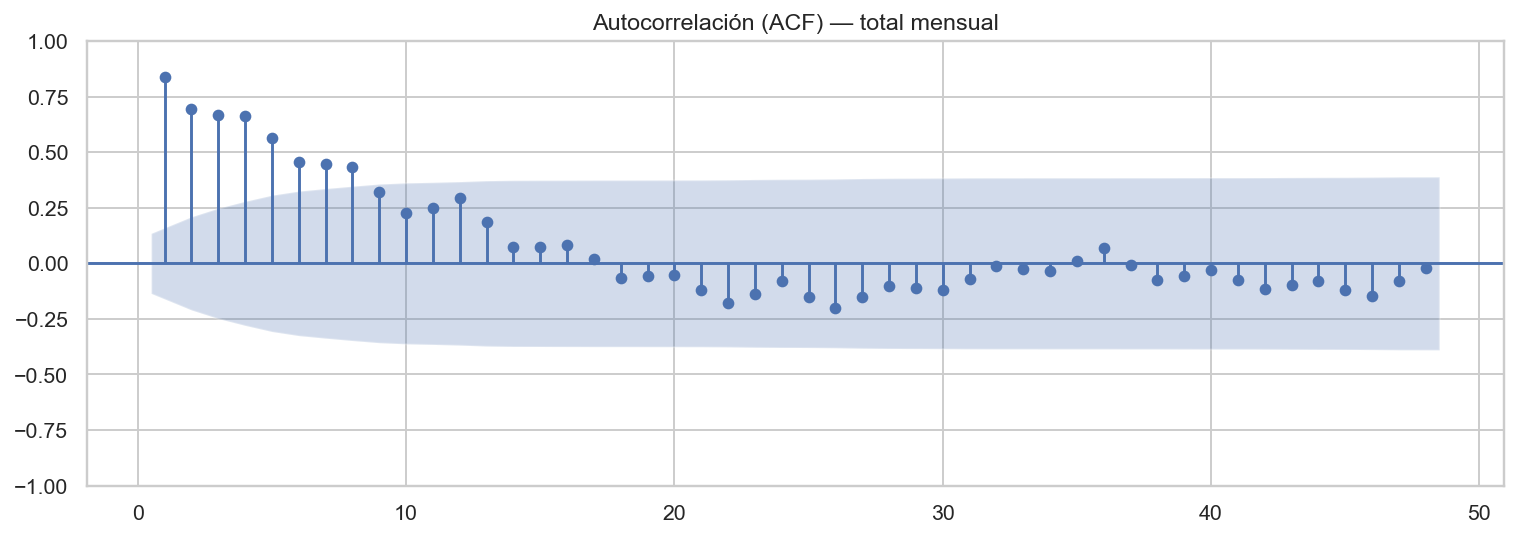

,Métrica,Valor
0,Inicio,2009-01
1,Fin,2026-06
2,Frecuencia,Mensual
3,Observaciones,210
4,Media mensual,248990.176637
5,Desviación estándar,100744.492958
6,Coeficiente de variación,0.404612
7,ACF rezago 1,0.838517
8,ACF rezago 12,0.307044
9,ADF nivel: estadístico,-3.070206


In [4]:
descomp = seasonal_decompose(total, model='additive', period=12, extrapolate_trend='freq')
fig = descomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Descomposición aditiva de la serie total mensual', y=1.02)
guardar(fig, '06_descomposicion_total.png')
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
plot_acf(total, lags=min(48, len(total)//2 - 1), ax=ax, zero=False)
ax.set_title('Autocorrelación (ACF) — total mensual')
guardar(fig, '07_acf_total.png')
plt.show()

adf_nivel = adfuller(total, autolag='AIC')
adf_diff = adfuller(total.diff().dropna(), autolag='AIC')
diagnostico = pd.DataFrame({'Métrica': ['Inicio', 'Fin', 'Frecuencia', 'Observaciones', 'Media mensual', 'Desviación estándar', 'Coeficiente de variación', 'ACF rezago 1', 'ACF rezago 12', 'ADF nivel: estadístico', 'ADF nivel: p-valor', 'ADF primera diferencia: estadístico', 'ADF primera diferencia: p-valor'],
                           'Valor': [total.index.min().strftime('%Y-%m'), total.index.max().strftime('%Y-%m'), 'Mensual', len(total), total.mean(), total.std(), total.std()/total.mean(), total.autocorr(1), total.autocorr(12), adf_nivel[0], adf_nivel[1], adf_diff[0], adf_diff[1]]})
display(diagnostico)
diagnostico.to_csv(OUT / 'diagnostico_serie_total.csv', index=False, encoding='utf-8-sig')

## 4. Interpretación preliminar

La decisión de diferenciación debe confirmarse más adelante con PACF, modelos candidatos y diagnósticos de residuos.

In [5]:
top_pais = datos.groupby('País')['Viajero'].sum().sort_values(ascending=False)
top_region = datos.groupby('Región')['Viajero'].sum().sort_values(ascending=False)
top_via = datos.groupby('Vía')['Viajero'].sum().sort_values(ascending=False)
cambio_2023 = anual.loc[2023, 'total_reportado'] / anual.loc[2022, 'total_reportado'] - 1
caida_2020 = anual.loc[2020, 'total_reportado'] / anual.loc[2019, 'total_reportado'] - 1
conclusion_adf = 'se rechaza' if adf_nivel[1] < .05 else 'no se rechaza'

display(Markdown(f'''
### Hallazgos para el avance

- La serie total tiene **{len(total)} observaciones mensuales**, desde **{total.index.min():%Y-%m}** hasta **{total.index.max():%Y-%m}**.
- La caída anual entre 2019 y 2020 fue de **{caida_2020:.1%}**, lo que evidencia el impacto de la pandemia.
- Entre 2022 y 2023 el total reportado cambió **{cambio_2023:.1%}**. Este resultado debe interpretarse junto con el cambio de definición de `Viajero` indicado en el enunciado.
- El principal país/mercado es **{top_pais.index[0]}** ({top_pais.iloc[0] / top_pais.sum():.1%} del acumulado), la región líder es **{top_region.index[0]}** ({top_region.iloc[0] / top_region.sum():.1%}) y la vía dominante es **{top_via.index[0]}** ({top_via.iloc[0] / top_via.sum():.1%}).
- La ACF es alta en el rezago 1 ({total.autocorr(1):.3f}) y conserva asociación en el rezago 12 ({total.autocorr(12):.3f}), por lo que se evaluarán modelos estacionales.
- La ADF en nivel tiene p-valor **{adf_nivel[1]:.4f}**: al 5%, **{conclusion_adf}** la hipótesis nula de raíz unitaria. Como hay quiebres estructurales, se compararán modelos con `d=0` y, si los diagnósticos lo requieren, `d=1`; la diferenciación estacional de período 12 se probará solo si se justifica.
- Los registros atípicos no se eliminaron automáticamente, pues pueden corresponder a flujos reales agregados.
'''))
print(f'Archivos de apoyo guardados en: {OUT}')


### Hallazgos para el avance

- La serie total tiene **210 observaciones mensuales**, desde **2009-01** hasta **2026-06**.
- La caída anual entre 2019 y 2020 fue de **-73.0%**, lo que evidencia el impacto de la pandemia.
- Entre 2022 y 2023 el total reportado cambió **-24.7%**. Este resultado debe interpretarse junto con el cambio de definición de `Viajero` indicado en el enunciado.
- El principal país/mercado es **El Salvador** (31.0% del acumulado), la región líder es **AMÉRICA DEL CENTRO** (71.5%) y la vía dominante es **Terrestre** (61.2%).
- La ACF es alta en el rezago 1 (0.839) y conserva asociación en el rezago 12 (0.307), por lo que se evaluarán modelos estacionales.
- La ADF en nivel tiene p-valor **0.0288**: al 5%, **se rechaza** la hipótesis nula de raíz unitaria. Como hay quiebres estructurales, se compararán modelos con `d=0` y, si los diagnósticos lo requieren, `d=1`; la diferenciación estacional de período 12 se probará solo si se justifica.
- Los registros atípicos no se eliminaron automáticamente, pues pueden corresponder a flujos reales agregados.


Archivos de apoyo guardados en: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB01\resultados_laboratorio_1
